In [ ]:
!pip install dandi pynwb h5py scipy -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import signal
from scipy.fft import fft, fftfreq
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 12 canales en el orden del NWB (Fig. 1b del paper)
LABELS = ['R_SUB','R_DG','R_CA1','R_CA3','R_AMD','R_ANT',
          'L_SUB','L_DG','L_CA1','L_CA3','L_AMD','L_ANT']


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/13

In [ ]:
DANDISET_ID = "001044"
DANDISET_VERSION = "0.240905.0159"
RATA = "RatB6"

print(f"Buscando archivos de {RATA} en DANDI...")

with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
    assets_b6 = [a for a in dandiset.get_assets() if RATA in a.path]

    seleccion = {}
    for asset in assets_b6:
        nombre = asset.path.split("/")[-1]
        fecha_str = nombre.split("ses-")[1][:8]
        mes = int(fecha_str[4:6])
        # Solo late stage (julio 2023) según Fig. 2 del paper
        if mes != 7:
            continue

        if '-non' in nombre:
            tipo = 'non'
            n = 0
        elif '-ictal' in nombre:
            tipo = 'ictal'
            n = int(nombre.split('-ictal')[1].split('_')[0])
        else:
            continue

        if tipo not in seleccion or n < seleccion[tipo]['n']:
            seleccion[tipo] = {'nombre': nombre, 'asset': asset,
                               'n': n, 'MB': asset.size/1e6}

print("\nArchivos seleccionados:")
for tipo, info in seleccion.items():
    print(f"  {tipo:5s} → {info['nombre']} ({info['MB']:.1f} MB)")

print("\nDescargando...")
for tipo, info in seleccion.items():
    if not os.path.exists(info['nombre']):
        print(f"  ⬇ {info['nombre']}")
        info['asset'].download(info['nombre'])
    else:
        print(f"  ✓ Ya existe: {info['nombre']}")
print("✓ Descarga completa.")


Buscando archivos de RatB6 en DANDI...

Archivos seleccionados:
  non   → sub-RatB6_ses-20230723-non_ecephys.nwb (44.3 MB)
  ictal → sub-RatB6_ses-20230724-ictal9_ecephys.nwb (195.2 MB)

Descargando...
  ⬇ sub-RatB6_ses-20230723-non_ecephys.nwb


INFO:dandi:Asset fa897829-d39a-4ce6-88b4-6f4af4bc3220 (44332201 bytes in 6 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/fa897829-d39a-4ce6-88b4-6f4af4bc3220/download/


  ⬇ sub-RatB6_ses-20230724-ictal9_ecephys.nwb


INFO:dandi:Asset b62a0af4-03a8-46d2-a8af-c803d9bb5f86 (195189494 bytes in 24 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/b62a0af4-03a8-46d2-a8af-c803d9bb5f86/download/


✓ Descarga completa.


# Carga y preprocesamiento

- Pasabanda 1-200 Hz (elimina drift DC residual)
- Notch 50 Hz (por si quedan armónicos)
- filtfilt → fase cero (no desplaza temporalmente los eventos)

In [ ]:
def preprocesar(x, fs=1000):
    """Filtro pasabanda 1-200 Hz + notch 50 Hz, fase cero."""
    sos = signal.butter(4, [1, 200], btype='band', fs=fs, output='sos')
    x = signal.sosfiltfilt(sos, x)
    b, a = signal.iirnotch(50, 30, fs)
    x = signal.filtfilt(b, a, x)
    return x


# Cargar ambos archivos, TODOS los canales
datos = {}
for tipo, info in seleccion.items():
    io = NWBHDF5IO(info['nombre'], mode='r', load_namespaces=True)
    nwb = io.read()
    nombre_es = list(nwb.acquisition.keys())[0]
    es = nwb.acquisition[nombre_es]
    fs = int(es.rate)
    raw = es.data[:]  # (600000, 12)

    # Preprocesar cada canal
    filt = np.zeros_like(raw, dtype=float)
    for ch in range(12):
        filt[:, ch] = preprocesar(raw[:, ch], fs)

    datos[tipo] = {
        'raw': raw,
        'filt': filt,
        'fs': fs,
        'nombre': nombre_es,
        'tiempo': np.arange(raw.shape[0]) / fs,
    }
    io.close()
    print(f"  {tipo:5s}: {nombre_es} — {raw.shape[0]/fs:.0f} s, {raw.shape[1]} canales")

print(f"\n✓ Datos cargados. fs = {fs} Hz.")


  non  : B6_2023_7_23-non1 — 600 s, 12 canales
  ictal: B6_2023_7_24-ictal1 — 600 s, 12 canales

✓ Datos cargados. fs = 1000 Hz.


#Vista de los 12 canales

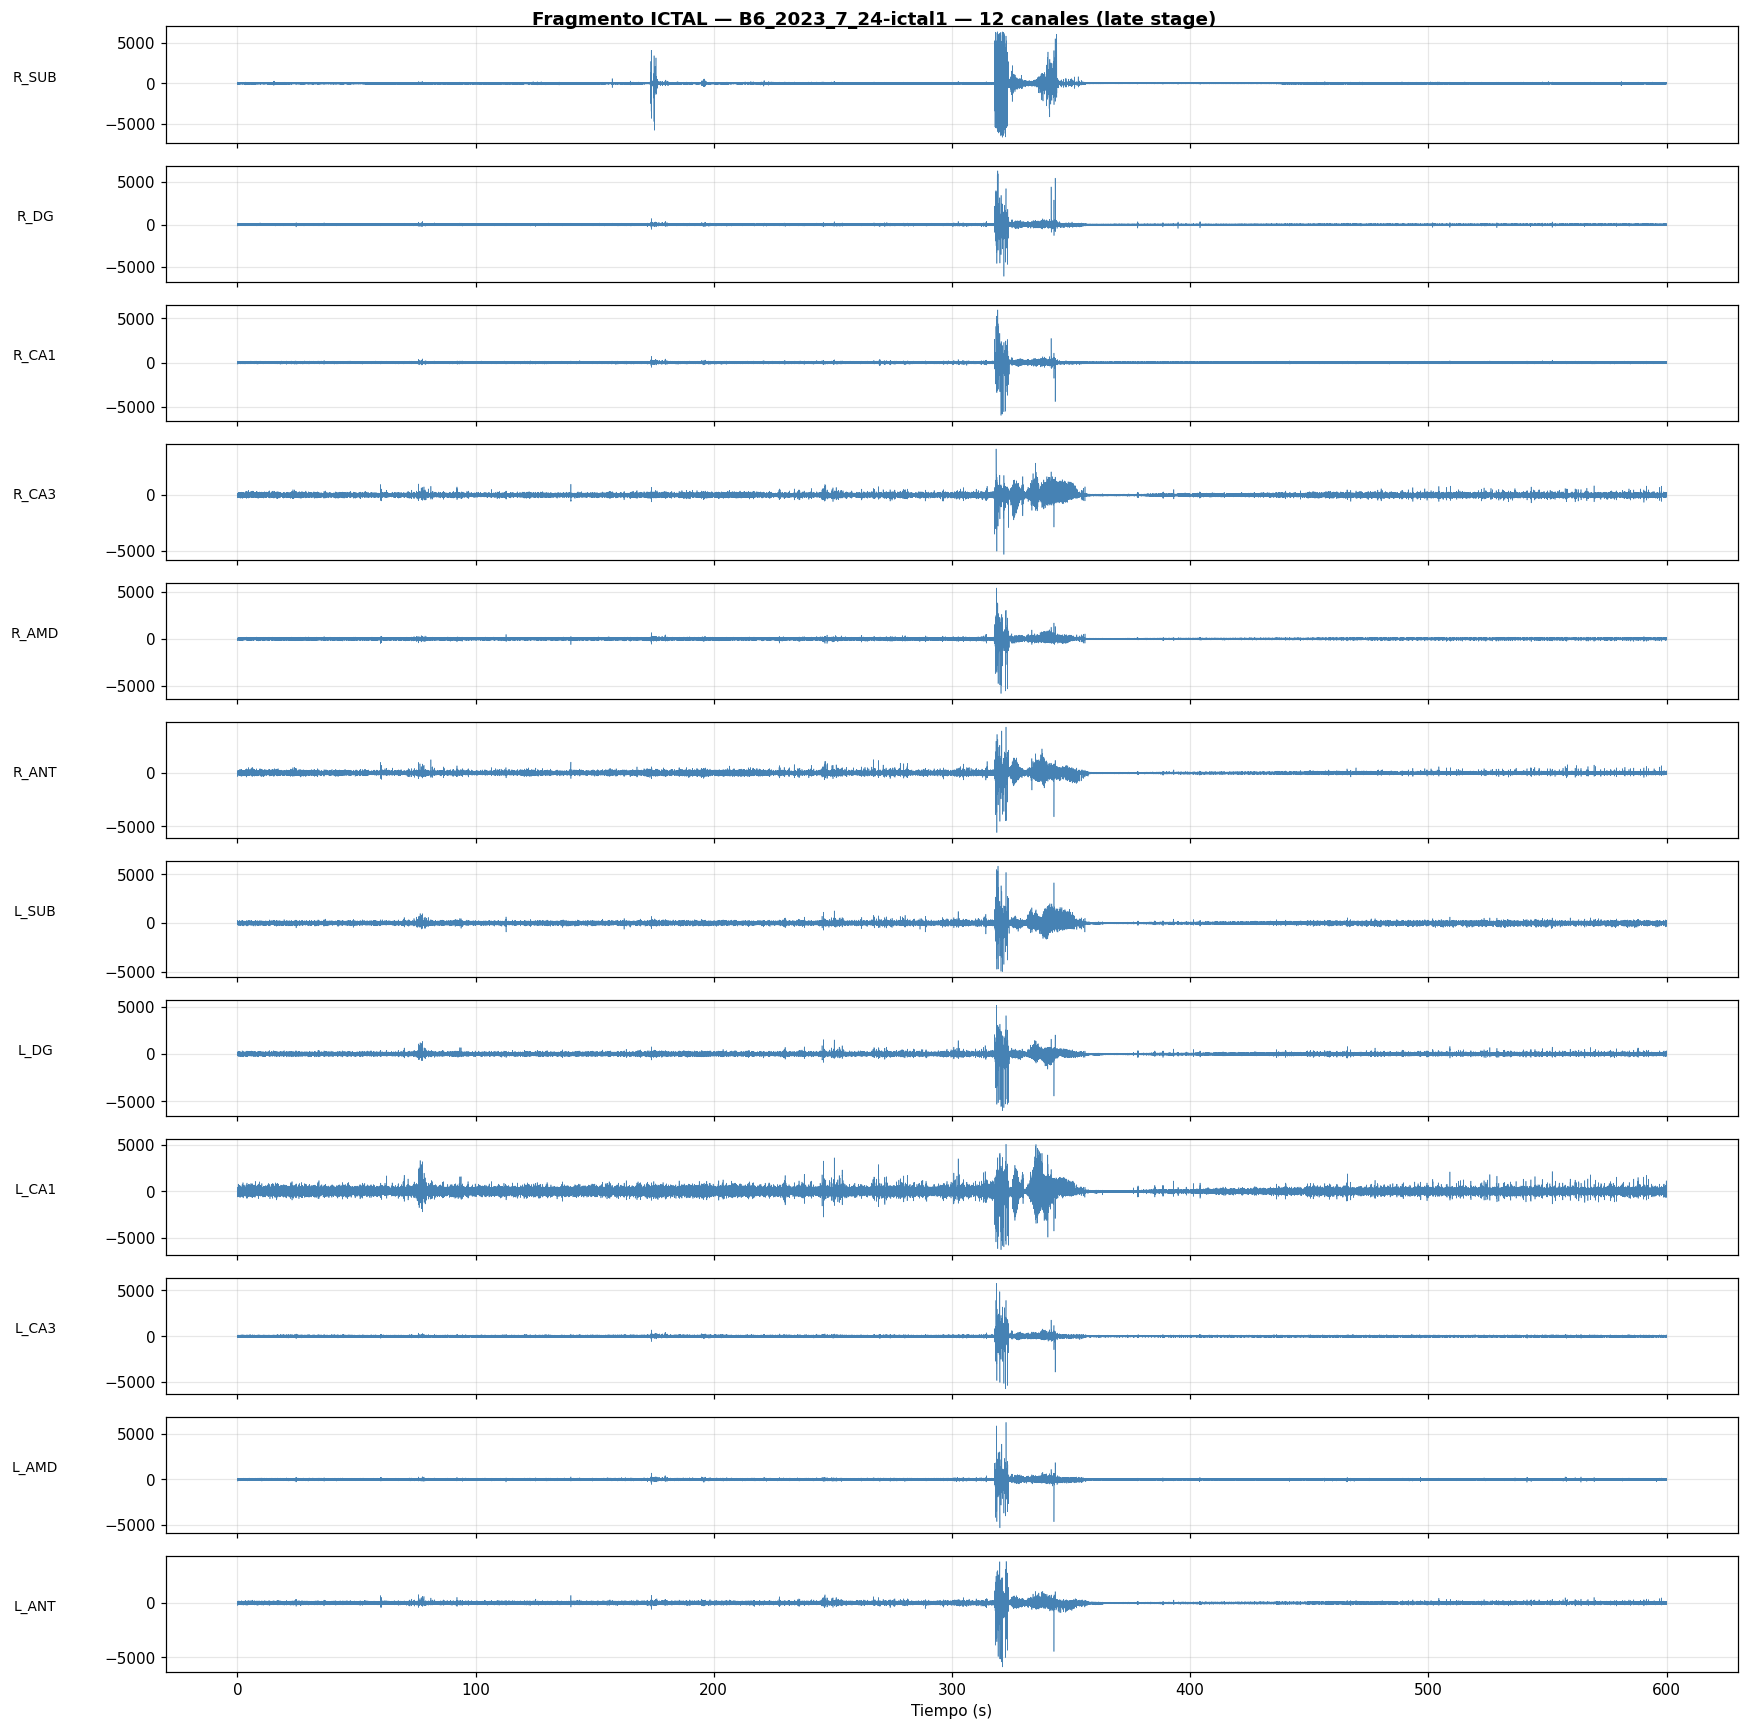

In [ ]:
ictal = datos['ictal']

fig, axes = plt.subplots(12, 1, figsize=(16, 16), sharex=True)
for i in range(12):
    axes[i].plot(ictal['tiempo'], ictal['filt'][:, i], linewidth=0.4, color='steelblue')
    axes[i].set_ylabel(LABELS[i], rotation=0, labelpad=45, fontsize=9)
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Tiempo (s)')
plt.suptitle(f"Fragmento ICTAL — {ictal['nombre']} — 12 canales (late stage)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#MÉTODO 1: Disimilitud por Autocorrelación

**Idea:** Calcula la autocorrelación R(τ) en ventanas deslizantes del ictal y la compara contra R(τ) de una referencia tomada del non.

 **Métrica:** Distancia euclidiana² normalizada entre las autocorrelaciones.

 **Umbral:** Mediana + 8·MAD (robusto a artefactos).

 Ventana movil: 2s
 Paso: 1s
 Refrencia: 60 s del non


  R_AMD: mediana=4.26, MAD=3.09, umbral=28.97, ventanas detectadas=10
  R_CA1: mediana=5.88, MAD=3.98, umbral=37.73, ventanas detectadas=9
  L_AMD: mediana=5.11, MAD=3.77, umbral=35.28, ventanas detectadas=10
  L_CA1: mediana=7.94, MAD=3.55, umbral=36.36, ventanas detectadas=74


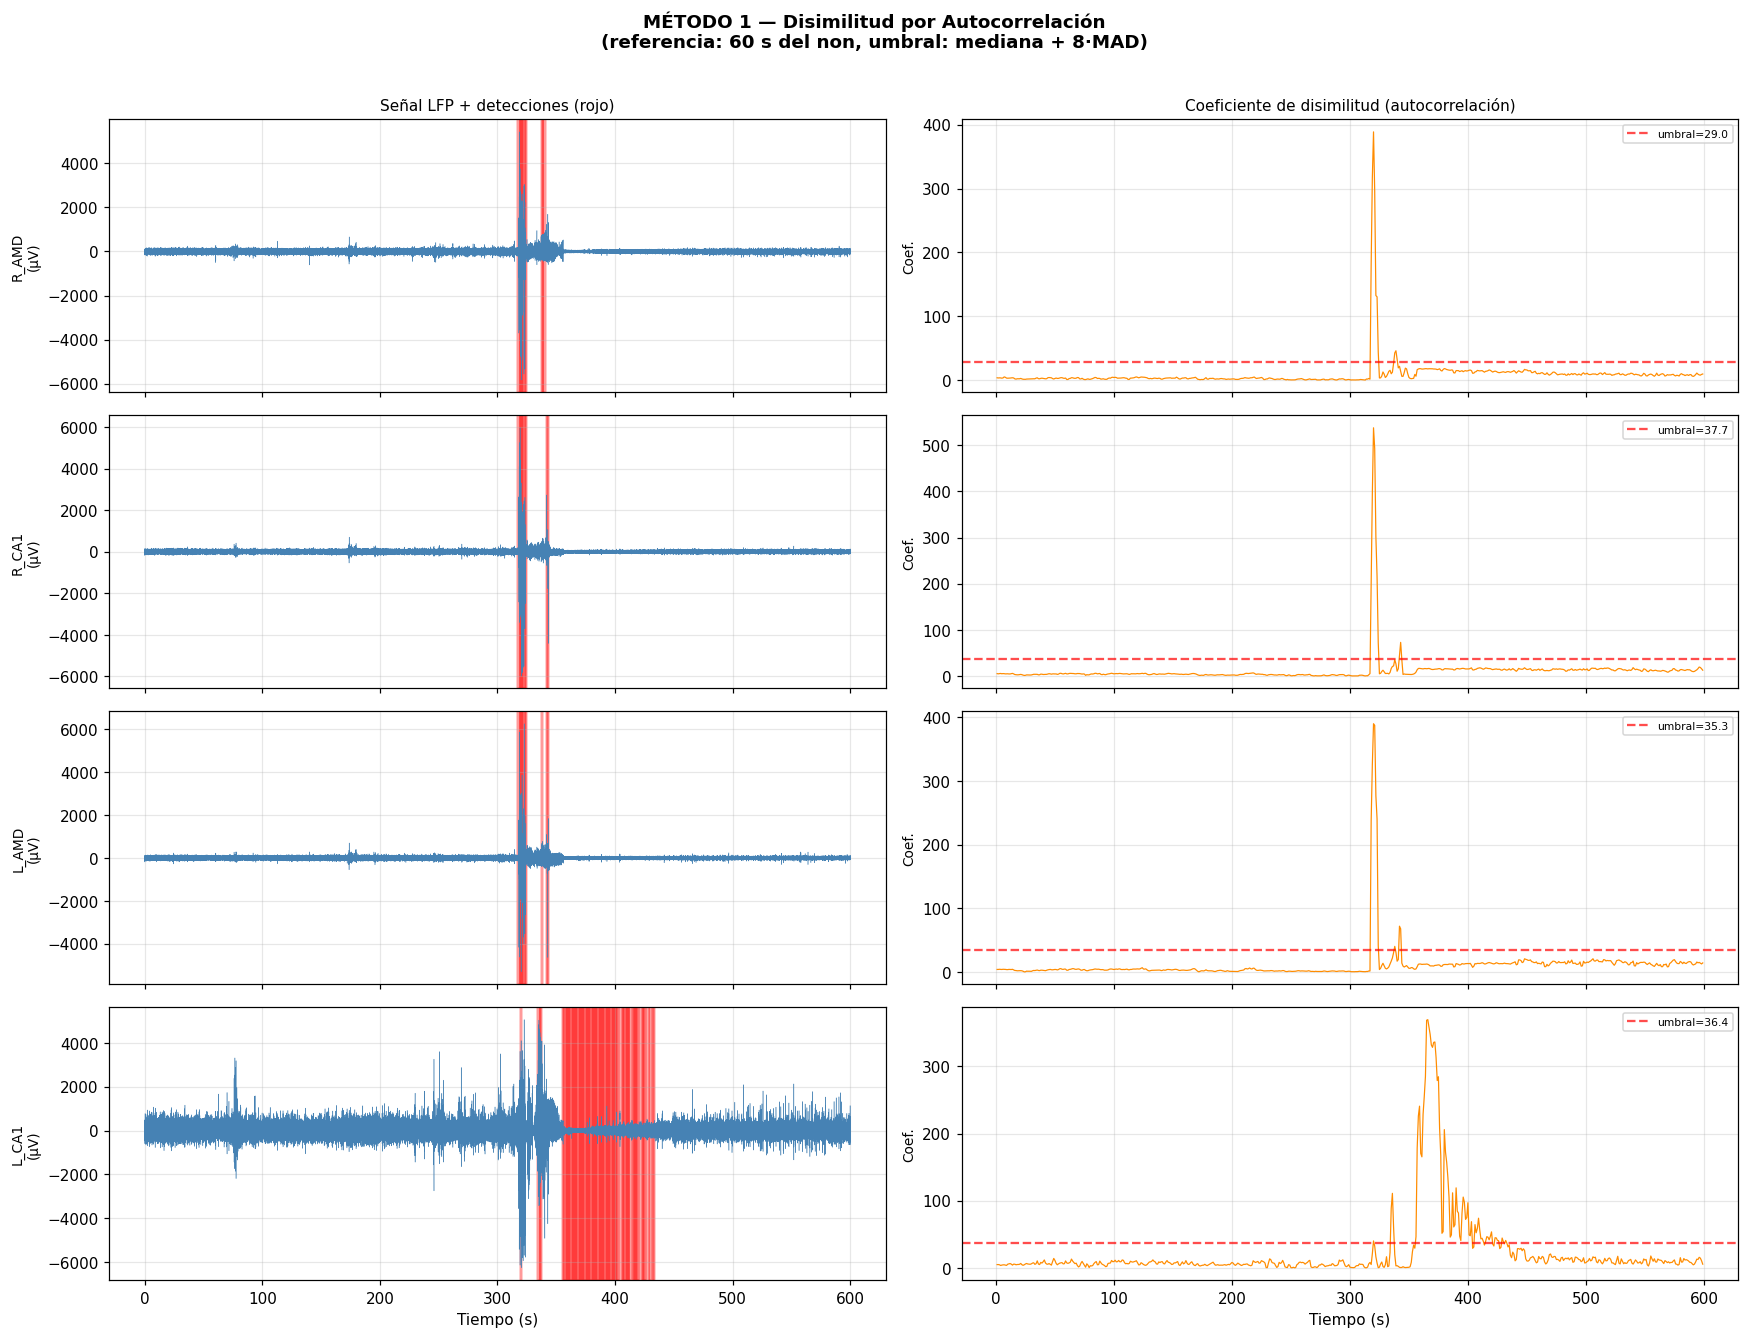

In [ ]:
def autocorr(x, n_lags):
    """Autocorrelación (no normalizada) hasta n_lags."""
    x = x - np.mean(x)
    n = len(x)
    R = np.array([np.sum(x[:n-k] * x[k:]) for k in range(n_lags + 1)])
    return R / n

def disimilitud_autocorr(ref, test, max_lag=50):
    """
    Distancia entre dos ventanas basada en sus autocorrelaciones.
    Normalizada por R(0) de ambas → invariante a escala global.
    """
    R_ref = autocorr(ref, max_lag)
    R_test = autocorr(test, max_lag)
    num = np.sum((R_ref - R_test) ** 2)
    den = R_ref[0] * R_test[0] + 1e-10
    return num / den

def detectar_metodo_autocorr(senal_ictal, senal_ref, fs=1000,
                              win_s=2.0, step_s=1.0, max_lag=50):
    """
    Disimilitud por autocorrelación con ventana deslizante.
    Retorna tiempos centrales y coeficientes.
    """
    win = int(win_s * fs)
    step = int(step_s * fs)
    coefs, t_centros = [], []
    t = 0
    while t + win <= len(senal_ictal):
        d = disimilitud_autocorr(senal_ref, senal_ictal[t:t+win], max_lag)
        coefs.append(d)
        t_centros.append((t + win/2) / fs)
        t += step
    return np.array(t_centros), np.array(coefs)


# Canales a analizar (4 canales del circuito epiléptico)
CANALES_ANALISIS = ['R_AMD', 'R_CA1', 'L_AMD', 'L_CA1']
IDX_CANALES = [LABELS.index(c) for c in CANALES_ANALISIS]

# Referencia: 60 s del MEDIO del non (segundos 250-310)
# Tomamos del medio para evitar artefactos de borde/inicio de grabación
REF_INI, REF_DUR = 250, 60

resultados_m1 = {}  # guardaremos los resultados de cada canal

fig, axes = plt.subplots(len(CANALES_ANALISIS), 2, figsize=(16, 3*len(CANALES_ANALISIS)),
                          sharex='col')

for row, (nombre_ch, idx_ch) in enumerate(zip(CANALES_ANALISIS, IDX_CANALES)):
    # Referencia del non
    ref = datos['non']['filt'][REF_INI*fs:(REF_INI+REF_DUR)*fs, idx_ch]
    # Señal ictal
    senal = datos['ictal']['filt'][:, idx_ch]

    # Calcular disimilitud
    t_c, coefs = detectar_metodo_autocorr(senal, ref, fs=fs)

    # Umbral: mediana + 8·MAD
    med = np.median(coefs)
    mad = np.median(np.abs(coefs - med))
    umbral = med + 8 * mad
    sobre = coefs > umbral

    resultados_m1[nombre_ch] = {
        't': t_c, 'coefs': coefs, 'umbral': umbral,
        'sobre': sobre, 'med': med, 'mad': mad
    }

    # Plot señal
    axes[row, 0].plot(ictal['tiempo'], senal, linewidth=0.3, color='steelblue')
    for idx in np.where(sobre)[0]:
        axes[row, 0].axvspan(t_c[idx]-1, t_c[idx]+1, alpha=0.25, color='red')
    axes[row, 0].set_ylabel(f'{nombre_ch}\n(µV)', fontsize=9)

    # Plot coeficiente
    axes[row, 1].plot(t_c, coefs, linewidth=0.8, color='darkorange')
    axes[row, 1].axhline(umbral, color='red', linestyle='--', alpha=0.7,
                          label=f'umbral={umbral:.1f}')
    axes[row, 1].set_ylabel('Coef.', fontsize=9)
    axes[row, 1].legend(fontsize=7, loc='upper right')

    n_det = np.sum(sobre)
    print(f"  {nombre_ch}: mediana={med:.2f}, MAD={mad:.2f}, "
          f"umbral={umbral:.2f}, ventanas detectadas={n_det}")

axes[0, 0].set_title('Señal LFP + detecciones (rojo)', fontsize=10)
axes[0, 1].set_title('Coeficiente de disimilitud (autocorrelación)', fontsize=10)
axes[-1, 0].set_xlabel('Tiempo (s)')
axes[-1, 1].set_xlabel('Tiempo (s)')

plt.suptitle('MÉTODO 1 — Disimilitud por Autocorrelación\n'
             '(referencia: 60 s del non, umbral: mediana + 8·MAD)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El hallazgo de L_CA1
L_CA1 tiene un comportamiento atípico: detecta de forma casi continua desde t=356 a t=433 (77 ventanas), mucho después de que la crisis terminó (~351s según M2). Esto podría ser:

Actividad post-ictal genuina en ese canal específico (depresión post-ictal con cambio de forma de onda sostenido)
Un canal "ruidoso" con calibración de umbral distinta (recordá que cada canal tiene su propio mediana+8MAD — si L_CA1 tiene una distribución de coefs más comprimida, el umbral puede ser más fácil de superar)

DEteccion si o no para metodo 1: Crisis (M1) = existe al menos un instante t en el que po rlo menos 2  canales (de CANALES_ANALISIS) tienen coef > umbral dentro de una ventana de coincidencia de ±3 segundos alrededor de t.

MÉTODO 1 — Criterio de crisis: coincidencia multicanal (±3s)
Nota: M1 detecta TRANSITORIOS (cambios de forma de onda), no estados
sostenidos. El criterio de duración ≥30s no aplica (ver discusión).
En su lugar, se exige sincronía: ≥2 canales con transitorio dentro
de una ventana de ±3s — coherente con la latencia de generalización
corta descripta por el paper para late stage.

  CRISIS DETECTADA (M1): primer evento t=315s, último evento t=346s
  Total de instantes con ≥2 canales en coincidencia: 25


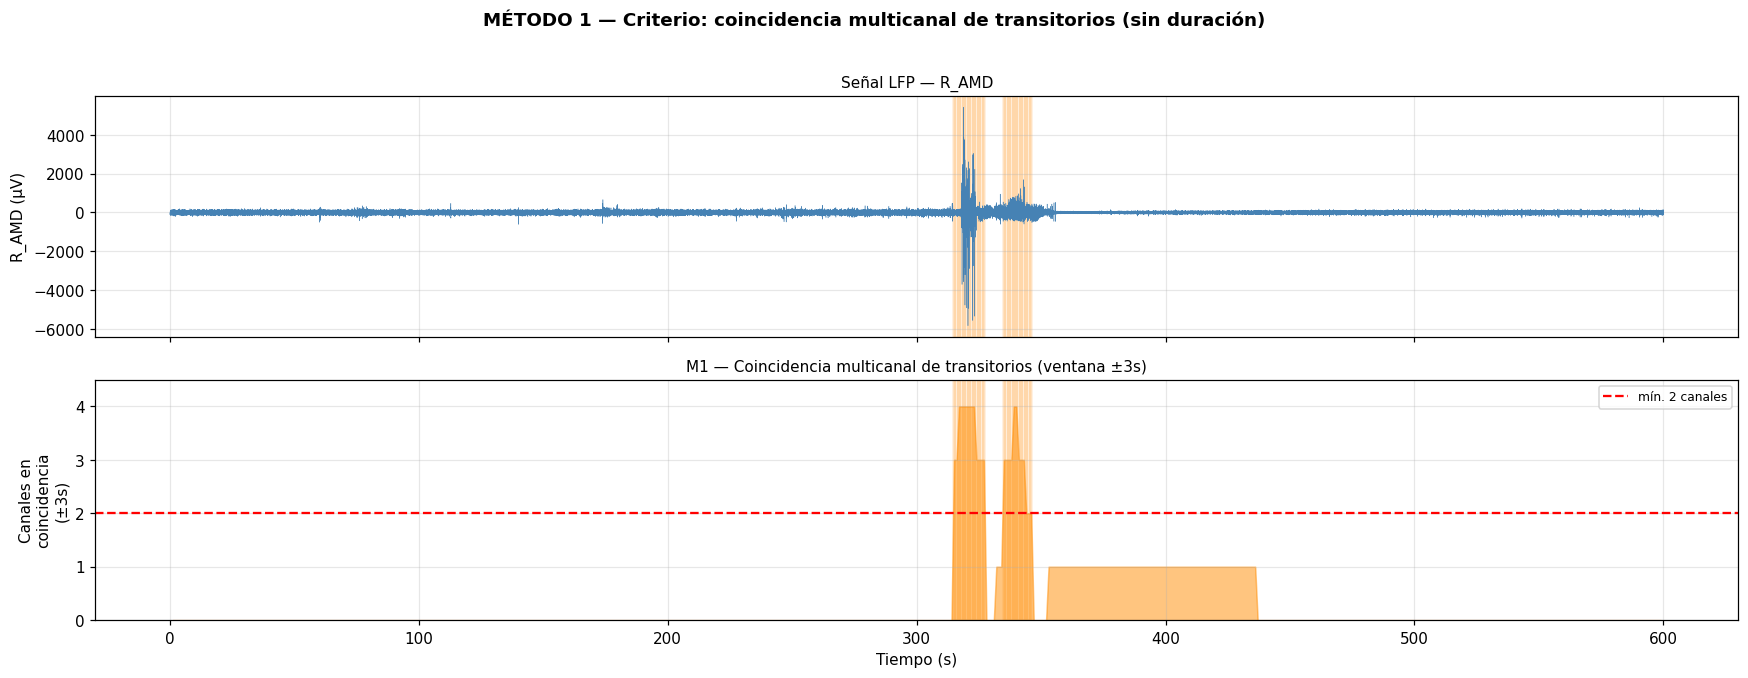

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CRITERIO DE CRISIS PARA MÉTODO 1: coincidencia multicanal de transitorios
#
# A diferencia de M2 (que mide un cambio SOSTENIDO en la distribución
# espectral, evaluable con un criterio de duración ≥30s), M1 mide cambios
# de FORMA de onda (autocorrelación normalizada) que son intrínsecamente
# TRANSITORIOS: se disparan en el onset y vuelven a baseline durante el
# cuerpo de la crisis (verificado: coef cae a niveles basales en la zona
# intermedia de la crisis).
#
# Por lo tanto, el criterio para M1 no es duración sino SINCRONÍA:
#   Crisis (M1) = existe t tal que ≥min_canales canales tienen
#                 coef > umbral dentro de una ventana ±W segundos.
# Esto es coherente con el paper: en late stage la latencia de
# generalización es muy corta, es decir, el onset transitorio aparece
# casi simultáneamente en múltiples sitios.
# ═══════════════════════════════════════════════════════════════════════

def detectar_crisis_m1_coincidencia(resultados, canales, min_canales=2, ventana_s=3):
    """
    Crisis (M1) = existe al menos un instante t donde >= min_canales
    canales tienen 'sobre'=True dentro de una ventana de +/- ventana_s
    segundos alrededor de t.

    Retorna:
      eventos: lista de dicts con 'tiempo_s' y 'n_canales' para cada
               instante que cumple el criterio
      n_coincidencia: array, para cada t del eje temporal de referencia,
               cuántos canales tienen un transitorio dentro de +/-ventana_s
    """
    t_ref = resultados[canales[0]]['t']
    n_coincidencia = np.zeros(len(t_ref), dtype=int)

    for i, t_centro in enumerate(t_ref):
        n_ch = 0
        for c in canales:
            t_c = resultados[c]['t']
            sobre = resultados[c]['sobre']
            mask = (t_c >= t_centro - ventana_s) & (t_c <= t_centro + ventana_s)
            if np.any(sobre & mask):
                n_ch += 1
        n_coincidencia[i] = n_ch

    cumple = n_coincidencia >= min_canales
    eventos = [{'tiempo_s': t_ref[i], 'n_canales': n_coincidencia[i]}
               for i in range(len(t_ref)) if cumple[i]]

    return eventos, n_coincidencia, cumple


print("=" * 60)
print("MÉTODO 1 — Criterio de crisis: coincidencia multicanal (±3s)")
print("=" * 60)
print("Nota: M1 detecta TRANSITORIOS (cambios de forma de onda), no estados")
print("sostenidos. El criterio de duración ≥30s no aplica (ver discusión).")
print("En su lugar, se exige sincronía: ≥2 canales con transitorio dentro")
print("de una ventana de ±3s — coherente con la latencia de generalización")
print("corta descripta por el paper para late stage.\n")

MIN_CANALES_M1 = 2
VENTANA_COINCIDENCIA = 3  # segundos

eventos_m1, n_coinc_m1, cumple_m1 = detectar_crisis_m1_coincidencia(
    resultados_m1, CANALES_ANALISIS,
    min_canales=MIN_CANALES_M1, ventana_s=VENTANA_COINCIDENCIA)

if eventos_m1:
    t_inicio = eventos_m1[0]['tiempo_s']
    t_fin    = eventos_m1[-1]['tiempo_s']
    print(f"  CRISIS DETECTADA (M1): primer evento t={t_inicio:.0f}s, "
          f"último evento t={t_fin:.0f}s")
    print(f"  Total de instantes con ≥{MIN_CANALES_M1} canales en coincidencia: "
          f"{len(eventos_m1)}")
else:
    print(f"  No se detectó coincidencia de ≥{MIN_CANALES_M1} canales "
          f"(criterio M1 no cumplido).")

# ── Visualización ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(ictal['tiempo'], datos['ictal']['filt'][:, LABELS.index('R_AMD')],
              linewidth=0.3, color='steelblue')
axes[0].set_ylabel('R_AMD (µV)')
axes[0].set_title('Señal LFP — R_AMD', fontsize=10)

t_ref_m1 = resultados_m1[CANALES_ANALISIS[0]]['t']
axes[1].fill_between(t_ref_m1, 0, n_coinc_m1, alpha=0.5, color='darkorange')
axes[1].axhline(MIN_CANALES_M1, color='red', linestyle='--',
                label=f'mín. {MIN_CANALES_M1} canales')
axes[1].set_ylabel('Canales en\ncoincidencia\n(±3s)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_title(f'M1 — Coincidencia multicanal de transitorios (ventana ±{VENTANA_COINCIDENCIA}s)',
                   fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, len(CANALES_ANALISIS)+0.5)

for ax in axes:
    for ev in eventos_m1:
        ax.axvspan(ev['tiempo_s']-0.5, ev['tiempo_s']+0.5, alpha=0.15, color='darkorange')

plt.suptitle('MÉTODO 1 — Criterio: coincidencia multicanal de transitorios (sin duración)',
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

CRISIS DETECTADA (M1): t=315s a t=346s
El panel inferior muestra dos picos bien definidos que alcanzan 4/4 canales: uno en ~317-323s (el onset) y otro en ~339-340s (el segundo evento intra-ictal que ya habíamos visto)
Después de t≈356s aparece esa meseta naranja en nivel 1 que se extiende hasta ~430s — es exactamente L_CA1 solo, el canal "raro" que detectamos antes. Como nunca llega a 2 canales, el criterio de coincidencia lo descarta automáticamente — no contamina la detección de crisis. Esto valida justamente la robustez del criterio que elegimos.

# MÉTODO 2: Disimilitud por Periodograma Móvil

**Idea:** Calcula la PSD (con Welch) en cada ventana deslizante, la normaliza
para que sume 1 (como una distribución de probabilidad), y mide la distancia
L1 contra la PSD normalizada de referencia.


**Ventaja:** Al normalizar, compara solo la *forma* espectral, no la amplitud.
Si la señal se amplifica pero mantiene las mismas proporciones entre bandas,
el coeficiente NO sube. Solo sube cuando la distribución de energía CAMBIA.

 **Umbral:** media + 3·std del coeficiente calculado sobre el non.

ventana movil de 2s
paso de 1 s

  R_AMD: umbral=0.942, ventanas detectadas=57
  R_CA1: umbral=0.952, ventanas detectadas=31
  L_AMD: umbral=0.893, ventanas detectadas=40
  L_CA1: umbral=1.027, ventanas detectadas=90


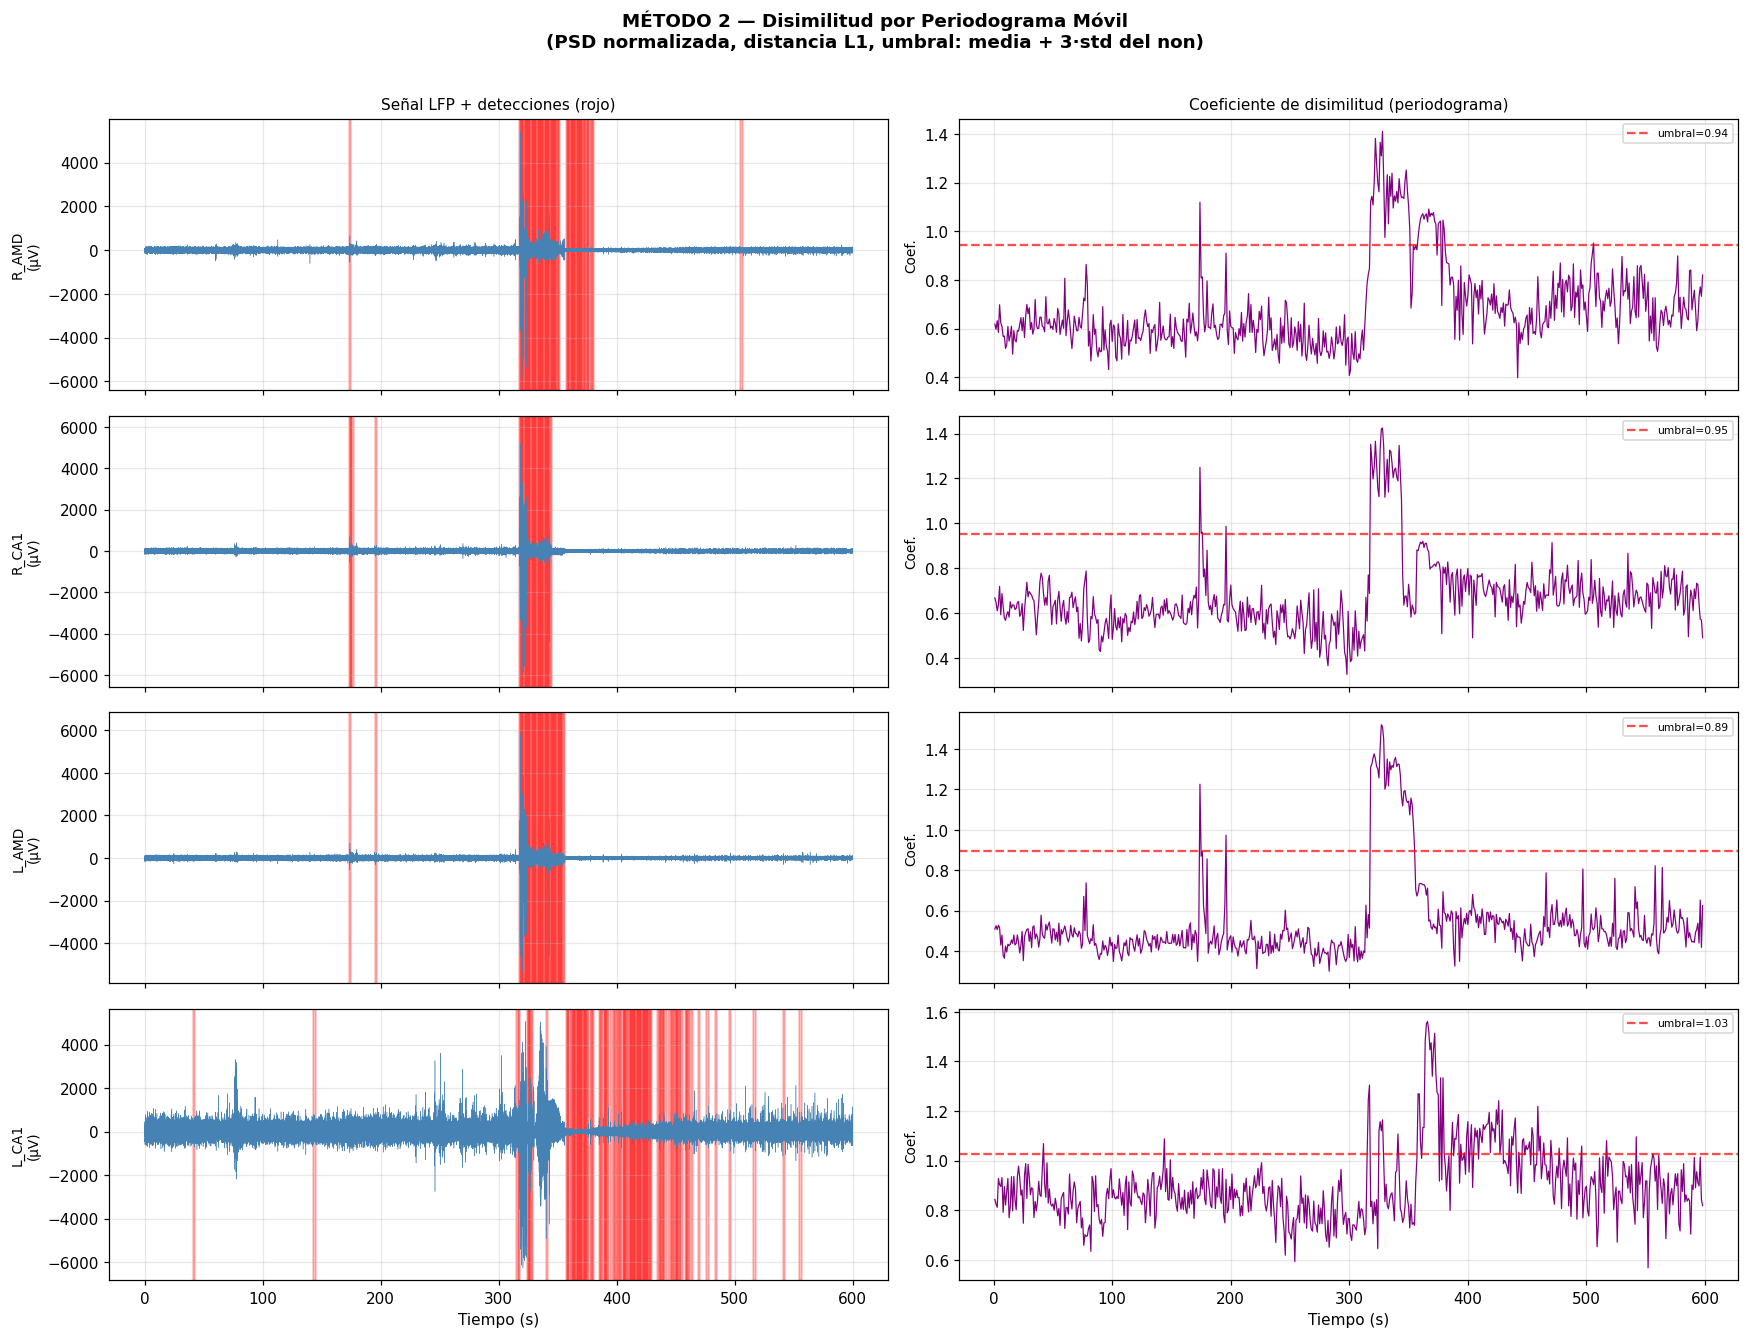

In [ ]:
def disimilitud_periodograma(senal_ictal, senal_ref, fs=1000,
                              win_s=2.0, step_s=1.0):
    """
    Periodograma móvil: calcula Welch en cada ventana deslizante
    del ictal, normaliza la PSD, y la compara (L1) contra la PSD
    normalizada de la referencia.
    """
    win = int(win_s * fs)
    step = int(step_s * fs)

    # PSD de referencia (Welch sobre toda la referencia)
    f_ref, psd_ref = signal.welch(senal_ref, fs=fs, nperseg=2*fs, noverlap=fs)
    psd_ref_norm = psd_ref / (np.sum(psd_ref) + 1e-10)

    coefs, t_centros = [], []
    for start in range(0, len(senal_ictal) - win, step):
        segmento = senal_ictal[start:start+win]
        f_test, psd_test = signal.welch(segmento, fs=fs, nperseg=win, noverlap=0)
        psd_test_norm = psd_test / (np.sum(psd_test) + 1e-10)

        # Distancia L1 (suma de diferencias absolutas)
        d = np.sum(np.abs(psd_test_norm - psd_ref_norm))
        coefs.append(d)
        t_centros.append((start + win/2) / fs)

    return np.array(t_centros), np.array(coefs), f_ref, psd_ref_norm


def umbral_desde_non(senal_non_restante, senal_ref, fs=1000,
                      win_s=2.0, step_s=1.0):
    """
    Calcula el umbral adaptativo pasando el periodograma móvil
    sobre el non (excluyendo la referencia), y usando media + 3·std.
    """
    win = int(win_s * fs)
    step = int(step_s * fs)

    f_ref, psd_ref = signal.welch(senal_ref, fs=fs, nperseg=2*fs, noverlap=fs)
    psd_ref_norm = psd_ref / (np.sum(psd_ref) + 1e-10)

    D_non = []
    for start in range(0, len(senal_non_restante) - win, step):
        seg = senal_non_restante[start:start+win]
        f_t, psd_t = signal.welch(seg, fs=fs, nperseg=win, noverlap=0)
        psd_t_norm = psd_t / (np.sum(psd_t) + 1e-10)
        D_non.append(np.sum(np.abs(psd_t_norm - psd_ref_norm)))

    D_non = np.array(D_non)
    return np.mean(D_non) + 3 * np.std(D_non), D_non


resultados_m2 = {}

fig, axes = plt.subplots(len(CANALES_ANALISIS), 2, figsize=(16, 3*len(CANALES_ANALISIS)),
                          sharex='col')

for row, (nombre_ch, idx_ch) in enumerate(zip(CANALES_ANALISIS, IDX_CANALES)):
    # Referencia: 60 s del medio del non
    ref = datos['non']['filt'][REF_INI*fs:(REF_INI+REF_DUR)*fs, idx_ch]
    # Non restante (después de la referencia, para calcular umbral)
    non_resto = datos['non']['filt'][(REF_INI+REF_DUR)*fs:, idx_ch]
    # Señal ictal
    senal = datos['ictal']['filt'][:, idx_ch]

    # Calcular disimilitud
    t_c, coefs, f_ref, psd_ref_n = disimilitud_periodograma(senal, ref, fs=fs)

    # Umbral desde el non (media + 3·std)
    umbral, D_non = umbral_desde_non(non_resto, ref, fs=fs)
    sobre = coefs > umbral

    resultados_m2[nombre_ch] = {
        't': t_c, 'coefs': coefs, 'umbral': umbral,
        'sobre': sobre, 'D_non': D_non
    }

    # Plot señal
    axes[row, 0].plot(ictal['tiempo'], senal, linewidth=0.3, color='steelblue')
    for idx in np.where(sobre)[0]:
        axes[row, 0].axvspan(t_c[idx]-1, t_c[idx]+1, alpha=0.25, color='red')
    axes[row, 0].set_ylabel(f'{nombre_ch}\n(µV)', fontsize=9)

    # Plot coeficiente
    axes[row, 1].plot(t_c, coefs, linewidth=0.8, color='purple')
    axes[row, 1].axhline(umbral, color='red', linestyle='--', alpha=0.7,
                          label=f'umbral={umbral:.2f}')
    axes[row, 1].set_ylabel('Coef.', fontsize=9)
    axes[row, 1].legend(fontsize=7, loc='upper right')

    n_det = np.sum(sobre)
    print(f"  {nombre_ch}: umbral={umbral:.3f}, ventanas detectadas={n_det}")

axes[0, 0].set_title('Señal LFP + detecciones (rojo)', fontsize=10)
axes[0, 1].set_title('Coeficiente de disimilitud (periodograma)', fontsize=10)
axes[-1, 0].set_xlabel('Tiempo (s)')
axes[-1, 1].set_xlabel('Tiempo (s)')

plt.suptitle('MÉTODO 2 — Disimilitud por Periodograma Móvil\n'
             '(PSD normalizada, distancia L1, umbral: media + 3·std del non)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Detección si o no : multicanal con criterio de duración ≥30 s para el metodo 2
#
 **Criterio del paper:** una crisis generalizada dura ≥30 s y se propaga
 a múltiples sitios.
 - Crisis si ≥2 de 4 canales superan el umbral
 - Durante ≥30 ventanas consecutivas (= 30 s con paso de 1 s)


DETECCIÓN MULTICANAL — Método 2 (Periodograma)
  Crisis 1: onset=318s, fin=351s, duración=33s


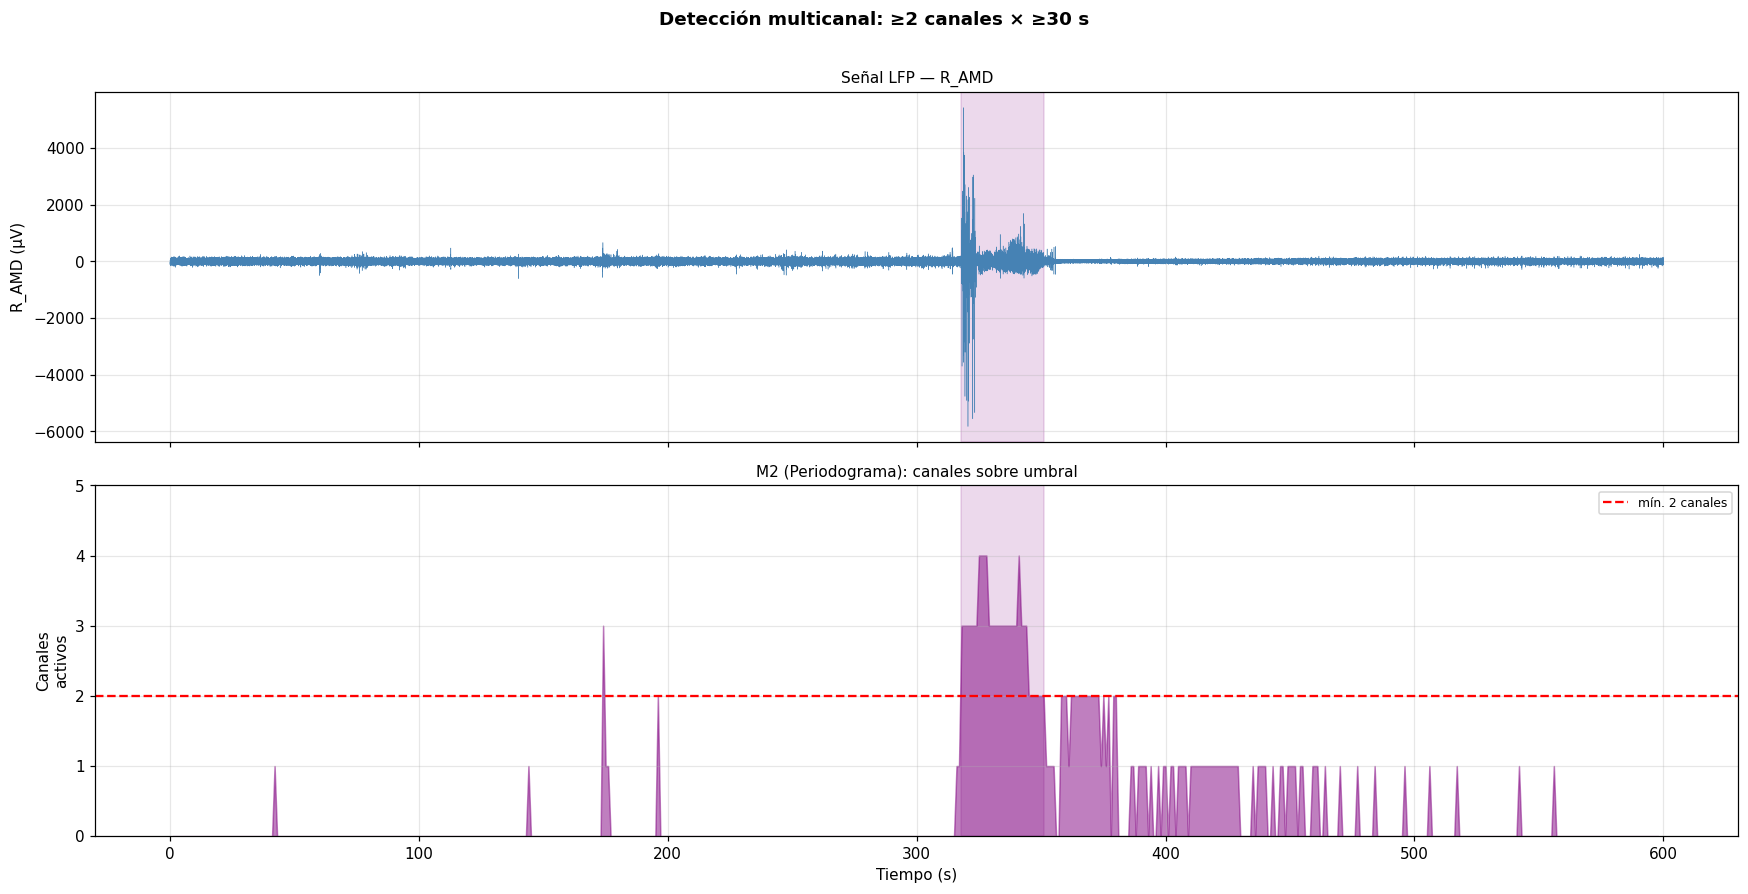

In [ ]:
def detectar_crisis_multicanal(resultados, canales, min_canales=2, min_duracion_s=30):
    """
    Combina la detección de múltiples canales.
    Crisis = al menos min_canales canales sobre el umbral,
    sostenido durante al menos min_duracion_s segundos.
    """
    # Matriz de detecciones: (n_ventanas, n_canales)
    n_ventanas = min(len(resultados[c]['sobre']) for c in canales)
    detecciones = np.zeros((n_ventanas, len(canales)), dtype=bool)
    for j, c in enumerate(canales):
        detecciones[:, j] = resultados[c]['sobre'][:n_ventanas]

    # ¿Cuántos canales superan el umbral en cada ventana?
    n_canales_activos = np.sum(detecciones, axis=1)
    multi = n_canales_activos >= min_canales

    # Buscar bloques consecutivos de ≥ min_duracion_s ventanas
    # (con paso de 1 s, cada ventana ≈ 1 s)
    crisis_detectadas = []
    en_crisis = False
    inicio = 0
    for i in range(len(multi)):
        if multi[i] and not en_crisis:
            inicio = i
            en_crisis = True
        elif not multi[i] and en_crisis:
            duracion = i - inicio
            if duracion >= min_duracion_s:
                t_arr = resultados[canales[0]]['t']
                crisis_detectadas.append({
                    'inicio_s': t_arr[inicio],
                    'fin_s': t_arr[i-1],
                    'duracion_s': t_arr[i-1] - t_arr[inicio],
                    'ventanas': duracion,
                })
            en_crisis = False
    # Cerrar si termina en crisis
    if en_crisis:
        duracion = len(multi) - inicio
        if duracion >= min_duracion_s:
            t_arr = resultados[canales[0]]['t']
            crisis_detectadas.append({
                'inicio_s': t_arr[inicio],
                'fin_s': t_arr[min(len(multi)-1, len(t_arr)-1)],
                'duracion_s': t_arr[min(len(multi)-1, len(t_arr)-1)] - t_arr[inicio],
                'ventanas': duracion,
            })

    return crisis_detectadas, n_canales_activos, multi

print()
print("=" * 60)
print("DETECCIÓN MULTICANAL — Método 2 (Periodograma)")
print("=" * 60)
crisis_m2, n_act_m2, multi_m2 = detectar_crisis_multicanal(
    resultados_m2, CANALES_ANALISIS, min_canales=2, min_duracion_s=30)
for i, c in enumerate(crisis_m2):
    print(f"  Crisis {i+1}: onset={c['inicio_s']:.0f}s, fin={c['fin_s']:.0f}s, "
          f"duración={c['duracion_s']:.0f}s")
if not crisis_m2:
    print("  (ninguna crisis detectada con criterio ≥30s)")

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Señal de un canal representativo
axes[0].plot(ictal['tiempo'], datos['ictal']['filt'][:, LABELS.index('R_AMD')],
             linewidth=0.3, color='steelblue')
axes[0].set_ylabel('R_AMD (µV)')
axes[0].set_title('Señal LFP — R_AMD', fontsize=10)


# Canales activos M2
t_m2 = resultados_m2[CANALES_ANALISIS[0]]['t'][:len(n_act_m2)]
axes[1].fill_between(t_m2, 0, n_act_m2, alpha=0.5, color='purple')
axes[1].axhline(2, color='red', linestyle='--', label='mín. 2 canales')
axes[1].set_ylabel('Canales\nactivos')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_title('M2 (Periodograma): canales sobre umbral', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 5)

# Sombrear crisis detectadas
for ax_idx in [0, 1]:
    for c in crisis_m2:
        axes[ax_idx].axvspan(c['inicio_s'], c['fin_s'],
                              alpha=0.15, color='purple')

plt.suptitle('Detección multicanal: ≥2 canales × ≥30 s',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Comparación lado a lado de ambos métodos

Graficamos ambos coeficientes superpuestos para un mismo canal,
para ver si detectan la crisis en el mismo momento y con qué sensibilidad.

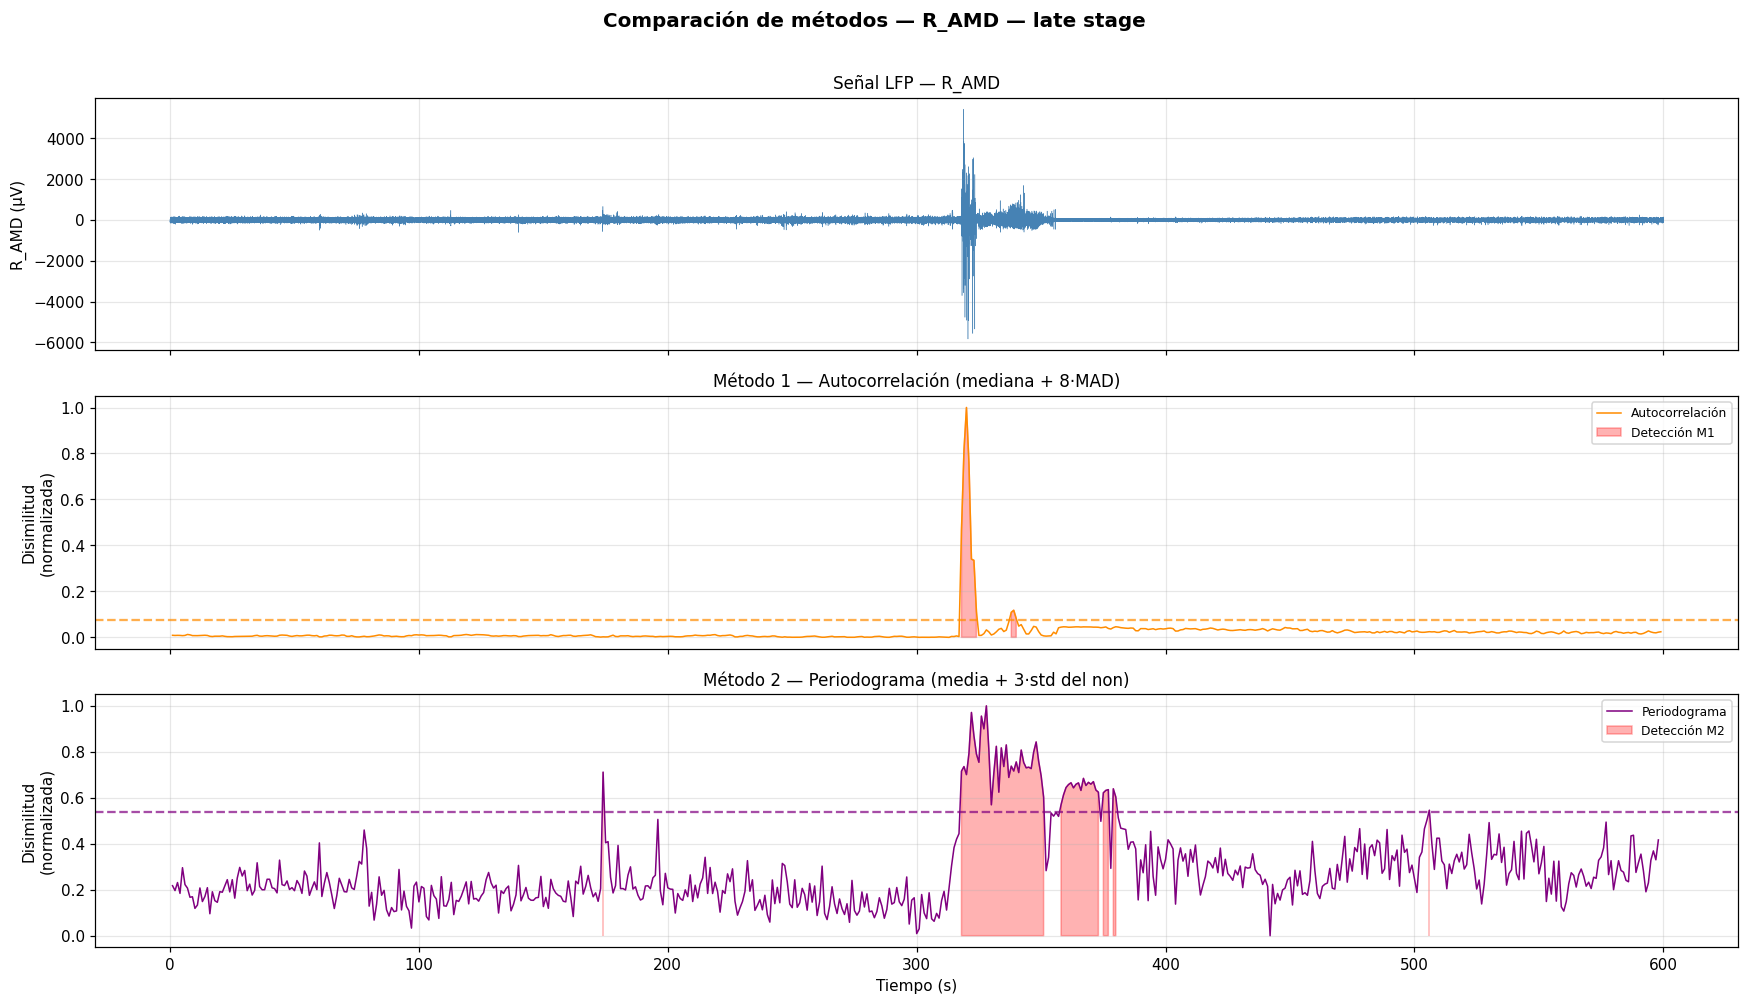

In [ ]:

# Elegimos R_AMD como canal principal (SOZ frecuente en late stage de B6)
CANAL_COMP = 'R_AMD'
idx_comp = LABELS.index(CANAL_COMP)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# Panel 1: señal LFP
axes[0].plot(ictal['tiempo'], datos['ictal']['filt'][:, idx_comp],
             linewidth=0.3, color='steelblue')
axes[0].set_ylabel(f'{CANAL_COMP} (µV)')
axes[0].set_title(f'Señal LFP — {CANAL_COMP}', fontsize=11)

# Panel 2: Método 1 (autocorrelación)
r1 = resultados_m1[CANAL_COMP]
# Normalizamos al rango [0, 1] para poder comparar visualmente
coefs1_norm = (r1['coefs'] - r1['coefs'].min()) / (r1['coefs'].max() - r1['coefs'].min())
umbral1_norm = (r1['umbral'] - r1['coefs'].min()) / (r1['coefs'].max() - r1['coefs'].min())

axes[1].plot(r1['t'], coefs1_norm, linewidth=1, color='darkorange',
             label='Autocorrelación')
axes[1].axhline(umbral1_norm, color='darkorange', linestyle='--', alpha=0.7)
axes[1].fill_between(r1['t'], 0, coefs1_norm,
                      where=r1['sobre'], alpha=0.3, color='red',
                      label='Detección M1')
axes[1].set_ylabel('Disimilitud\n(normalizada)')
axes[1].set_title('Método 1 — Autocorrelación (mediana + 8·MAD)', fontsize=11)
axes[1].legend(fontsize=8, loc='upper right')

# Panel 3: Método 2 (periodograma)
r2 = resultados_m2[CANAL_COMP]
coefs2_norm = (r2['coefs'] - r2['coefs'].min()) / (r2['coefs'].max() - r2['coefs'].min())
umbral2_norm = (r2['umbral'] - r2['coefs'].min()) / (r2['coefs'].max() - r2['coefs'].min())

axes[2].plot(r2['t'], coefs2_norm, linewidth=1, color='purple',
             label='Periodograma')
axes[2].axhline(umbral2_norm, color='purple', linestyle='--', alpha=0.7)
axes[2].fill_between(r2['t'], 0, coefs2_norm,
                      where=r2['sobre'], alpha=0.3, color='red',
                      label='Detección M2')
axes[2].set_ylabel('Disimilitud\n(normalizada)')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_title('Método 2 — Periodograma (media + 3·std del non)', fontsize=11)
axes[2].legend(fontsize=8, loc='upper right')

plt.suptitle(f'Comparación de métodos — {CANAL_COMP} — late stage',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Estadísticas de concordancia
n_min = min(len(r1['sobre']), len(r2['sobre']))
sobre_ambos  = r1['sobre'][:n_min] & r2['sobre'][:n_min]
sobre_alguno = r1['sobre'][:n_min] | r2['sobre'][:n_min]
concordancia = np.sum(sobre_ambos) / (np.sum(sobre_alguno) + 1e-10) * 100


M1 (autocorrelación normalizada): la forma temporal cambia abruptamente solo en las transiciones (onset, y posiblemente algún evento intra-ictal en t=338-340) → es un detector de transitorios, no de estado sostenido
M2 (PSD normalizada): la distribución espectral cambia y se mantiene cambiada durante toda la crisis → naturalmente compatible con duración ≥30s


Deteccion general:
Si ambos detectores detectan para un intervalo de tiempo superpuesto
Crisis CONFIRMADA = [t_inicio_M1, t_fin_M1] ∩ [t_inicio_M2, t_fin_M2] ≠ ∅
reduce falsos positivos (si uno solo dispara por una razón espuria propia de su dominio, no alcanza)
 limitación: este criterio prioriza especificidad sobre sensibilidad.

CRITERIO FINAL — Confirmación cruzada M1 ∩ M2
  M1: ventana de coincidencia = [315s, 346s]
  M2: ventana(s) de duración sostenida:
      [318s, 351s] (duración=33s)

  ✓ CRISIS CONFIRMADA
    Solapamiento M1∩M2: [318s, 346s]
    M1 (transitorio sincrónico) + M2 (régimen espectral sostenido)


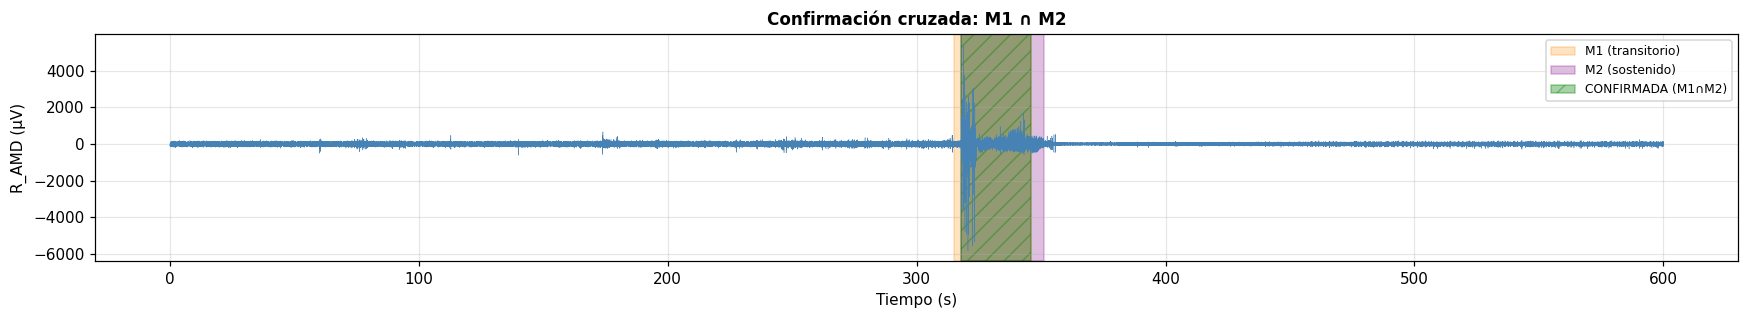

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CRITERIO FINAL: Crisis CONFIRMADA = M1 y M2 coinciden temporalmente
#
# M1 (coincidencia multicanal de transitorios) y M2 (duración sostenida
# ≥30s) miden propiedades distintas y complementarias de la señal:
# forma de onda vs distribución espectral. Si AMBOS marcan actividad
# en una misma ventana temporal, esto constituye evidencia cruzada
# desde dos dominios de análisis independientes → crisis CONFIRMADA.
#
# Trade-off: este criterio (AND) prioriza especificidad sobre sensibilidad.
# Un evento donde solo M1 o solo M2 detecte quedaría como "candidato",
# no "confirmado".
# ═══════════════════════════════════════════════════════════════════════

def hay_solapamiento(ini1, fin1, ini2, fin2):
    """True si los intervalos [ini1,fin1] y [ini2,fin2] se superponen."""
    return max(ini1, ini2) <= min(fin1, fin2)

print("=" * 60)
print("CRITERIO FINAL — Confirmación cruzada M1 ∩ M2")
print("=" * 60)

# Intervalo de M1 (coincidencia multicanal)
if eventos_m1:
    m1_ini = eventos_m1[0]['tiempo_s']
    m1_fin = eventos_m1[-1]['tiempo_s']
    print(f"  M1: ventana de coincidencia = [{m1_ini:.0f}s, {m1_fin:.0f}s]")
else:
    m1_ini, m1_fin = None, None
    print("  M1: no detectó coincidencia multicanal.")

# Intervalo(s) de M2 (duración sostenida)
if crisis_m2:
    print(f"  M2: ventana(s) de duración sostenida:")
    for c in crisis_m2:
        print(f"      [{c['inicio_s']:.0f}s, {c['fin_s']:.0f}s] "
              f"(duración={c['duracion_s']:.0f}s)")
else:
    print("  M2: no detectó crisis con criterio ≥30s.")

# ── Veredicto final ────────────────────────────────────────────────────
print()
confirmada = False
if m1_ini is not None and crisis_m2:
    for c in crisis_m2:
        if hay_solapamiento(m1_ini, m1_fin, c['inicio_s'], c['fin_s']):
            ini_conf = max(m1_ini, c['inicio_s'])
            fin_conf = min(m1_fin, c['fin_s'])
            print(f"  ✓ CRISIS CONFIRMADA")
            print(f"    Solapamiento M1∩M2: [{ini_conf:.0f}s, {fin_conf:.0f}s]")
            print(f"    M1 (transitorio sincrónico) + M2 (régimen espectral sostenido)")
            confirmada = True
            break

if not confirmada:
    print("  ✗ Sin confirmación cruzada — M1 y M2 no coinciden temporalmente,")
    print("    o alguno de los dos no detectó nada.")

# ── Visualización resumen ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(ictal['tiempo'], datos['ictal']['filt'][:, LABELS.index('R_AMD')],
        linewidth=0.3, color='steelblue')

if m1_ini is not None:
    ax.axvspan(m1_ini, m1_fin, alpha=0.25, color='darkorange', label='M1 (transitorio)')
for c in crisis_m2:
    ax.axvspan(c['inicio_s'], c['fin_s'], alpha=0.25, color='purple', label='M2 (sostenido)')
if confirmada:
    ax.axvspan(ini_conf, fin_conf, alpha=0.35, color='green',
               label='CONFIRMADA (M1∩M2)', hatch='//')

ax.set_ylabel('R_AMD (µV)')
ax.set_xlabel('Tiempo (s)')
ax.set_title('Confirmación cruzada: M1 ∩ M2', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

Para chequear que para un fragmento sin crisis (de un mimso animal) donde no hay crisis funciona y no detecta crisis--> se uso non2 y se lo comparo con el mimso non1 que se utilizo para detectar crisis previamente con M1 y M2

CONTROL DE ESPECIFICIDAD — fragmento NON2 (sin crisis)
  Cargado: B6_2023_7_23-non2 — 600s, 12 canales

  R_AMD: M1 ventanas>umbral=  0 | M2 ventanas>umbral=  0
  R_CA1: M1 ventanas>umbral=  0 | M2 ventanas>umbral=  1
  L_AMD: M1 ventanas>umbral=  0 | M2 ventanas>umbral=  0
  L_CA1: M1 ventanas>umbral=  0 | M2 ventanas>umbral= 32

  M1 — instantes con ≥2 canales en coincidencia: 0
  M2 — crisis detectadas (≥30s): 0

  ✓ ESPECIFICIDAD OK — ningún método detecta crisis en non2.


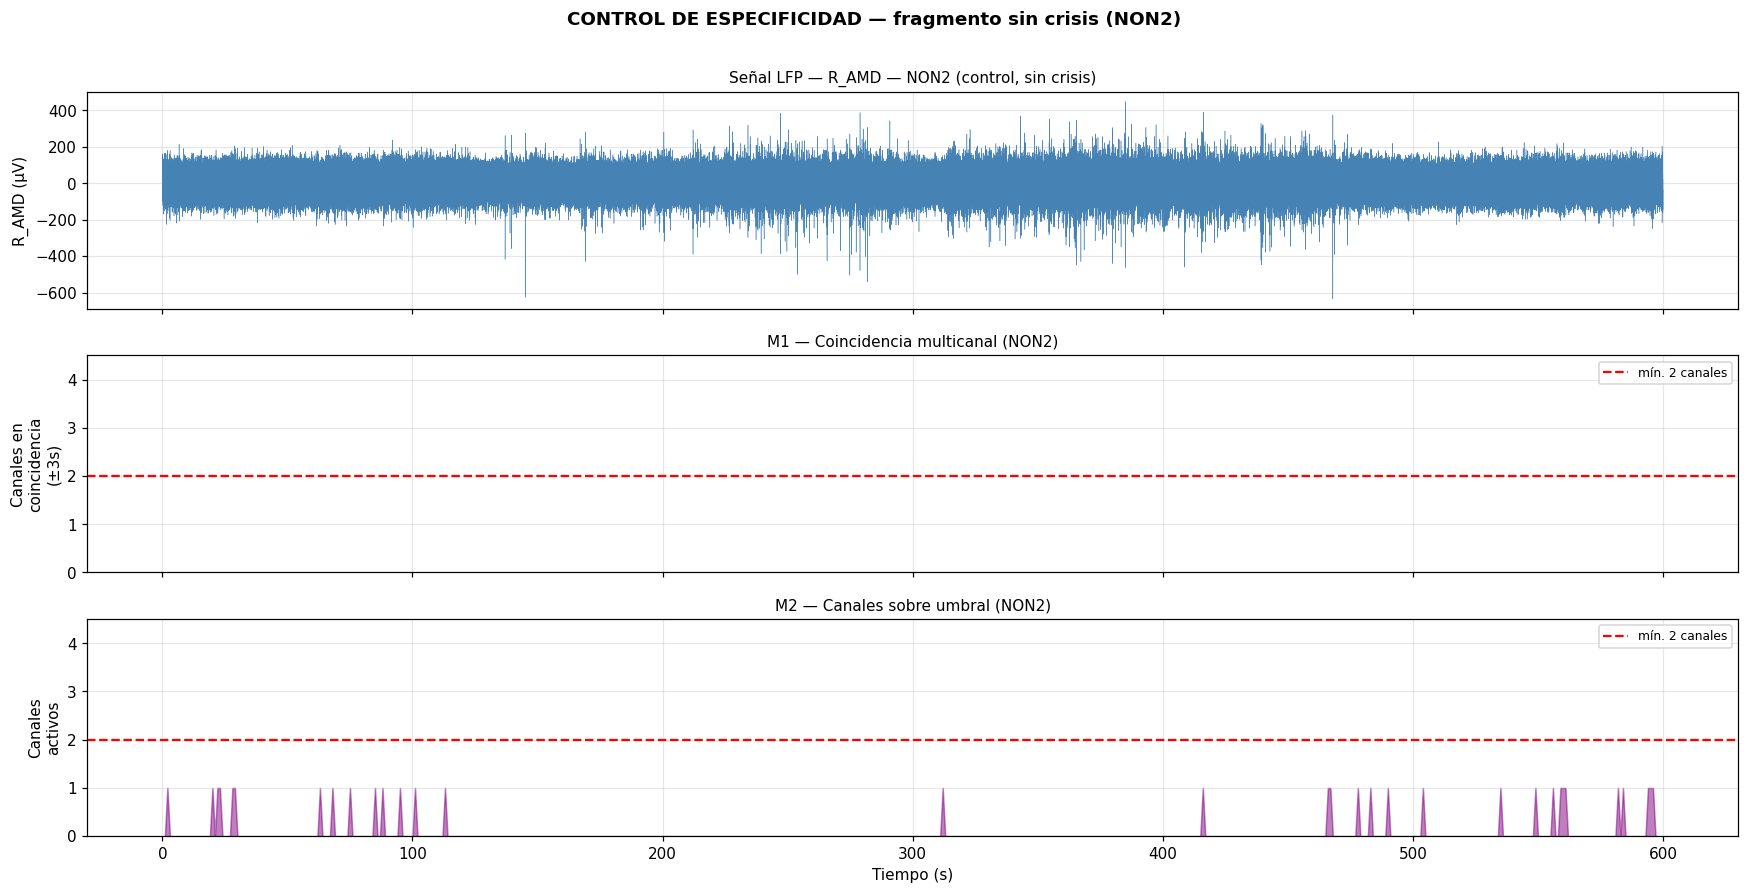

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CONTROL DE ESPECIFICIDAD: ¿el detector dispara en un fragmento SIN crisis?
#
# Se aplica el pipeline completo (M1 + M2 + criterios de crisis) sobre
# 'non2', un segundo fragmento interictal NUNCA usado para construir
# la referencia ni para calibrar los umbrales (eso evita el problema
# de evaluar el detector sobre los mismos datos con los que se calibró).
#
# Resultado esperado: NINGUNA crisis detectada por ninguno de los dos
# criterios (M1: coincidencia multicanal, M2: duración ≥30s).
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("CONTROL DE ESPECIFICIDAD — fragmento NON2 (sin crisis)")
print("=" * 60)

# Cargar non2 (mismo procedimiento que para 'datos', pero archivo non2)
io2 = NWBHDF5IO(seleccion['non']['nombre'], mode='r', load_namespaces=True)
nwb2 = io2.read()
# 'non2' está en el MISMO archivo que 'non1', como segunda serie de acquisition
nombre_non2 = [k for k in nwb2.acquisition.keys() if 'non2' in k][0]
raw_non2 = nwb2.acquisition[nombre_non2].data[:]
io2.close()

filt_non2 = np.zeros_like(raw_non2, dtype=float)
for ch in range(12):
    filt_non2[:, ch] = preprocesar(raw_non2[:, ch], fs)

tiempo_non2 = np.arange(raw_non2.shape[0]) / fs
print(f"  Cargado: {nombre_non2} — {raw_non2.shape[0]/fs:.0f}s, {raw_non2.shape[1]} canales\n")

# ── Aplicar M1 y M2 sobre non2, usando la MISMA ref y umbrales ya fijados ──
resultados_m1_non2 = {}
resultados_m2_non2 = {}

for nombre_ch, idx_ch in zip(CANALES_ANALISIS, IDX_CANALES):
    ref = datos['non']['filt'][REF_INI*fs:(REF_INI+REF_DUR)*fs, idx_ch]
    senal_non2 = filt_non2[:, idx_ch]

    # M1
    t_c1, coefs1 = detectar_metodo_autocorr(senal_non2, ref, fs=fs)
    umbral1 = resultados_m1[nombre_ch]['umbral']  # umbral YA calibrado (no recalibrar)
    sobre1 = coefs1 > umbral1
    resultados_m1_non2[nombre_ch] = {'t': t_c1, 'coefs': coefs1,
                                       'umbral': umbral1, 'sobre': sobre1}

    # M2
    t_c2, coefs2, _, _ = disimilitud_periodograma(senal_non2, ref, fs=fs)
    umbral2 = resultados_m2[nombre_ch]['umbral']  # umbral YA calibrado
    sobre2 = coefs2 > umbral2
    resultados_m2_non2[nombre_ch] = {'t': t_c2, 'coefs': coefs2,
                                       'umbral': umbral2, 'sobre': sobre2}

    print(f"  {nombre_ch}: M1 ventanas>umbral={np.sum(sobre1):3d} | "
          f"M2 ventanas>umbral={np.sum(sobre2):3d}")

# ── Aplicar los MISMOS criterios de crisis ─────────────────────────────
print()
eventos_m1_non2, n_coinc_m1_non2, _ = detectar_crisis_m1_coincidencia(
    resultados_m1_non2, CANALES_ANALISIS,
    min_canales=MIN_CANALES_M1, ventana_s=VENTANA_COINCIDENCIA)

crisis_m2_non2, n_act_m2_non2, _ = detectar_crisis_multicanal(
    resultados_m2_non2, CANALES_ANALISIS, min_canales=2, min_duracion_s=30)

print(f"  M1 — instantes con ≥{MIN_CANALES_M1} canales en coincidencia: {len(eventos_m1_non2)}")
print(f"  M2 — crisis detectadas (≥30s): {len(crisis_m2_non2)}")

if not eventos_m1_non2 and not crisis_m2_non2:
    print("\n  ✓ ESPECIFICIDAD OK — ningún método detecta crisis en non2.")
else:
    print("\n  ⚠ Atención: se detectó actividad tipo-crisis en un fragmento sin crisis.")

# ── Visualización ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

axes[0].plot(tiempo_non2, filt_non2[:, LABELS.index('R_AMD')],
              linewidth=0.3, color='steelblue')
axes[0].set_ylabel('R_AMD (µV)')
axes[0].set_title('Señal LFP — R_AMD — NON2 (control, sin crisis)', fontsize=10)

t_ref_non2 = resultados_m1_non2[CANALES_ANALISIS[0]]['t']
axes[1].fill_between(t_ref_non2, 0, n_coinc_m1_non2, alpha=0.5, color='darkorange')
axes[1].axhline(MIN_CANALES_M1, color='red', linestyle='--', label=f'mín. {MIN_CANALES_M1} canales')
axes[1].set_ylabel('Canales en\ncoincidencia\n(±3s)')
axes[1].set_title('M1 — Coincidencia multicanal (NON2)', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, len(CANALES_ANALISIS)+0.5)

t_ref_m2_non2 = resultados_m2_non2[CANALES_ANALISIS[0]]['t']
axes[2].fill_between(t_ref_m2_non2, 0, n_act_m2_non2, alpha=0.5, color='purple')
axes[2].axhline(2, color='red', linestyle='--', label='mín. 2 canales')
axes[2].set_ylabel('Canales\nactivos')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_title('M2 — Canales sobre umbral (NON2)', fontsize=10)
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, len(CANALES_ANALISIS)+0.5)

plt.suptitle('CONTROL DE ESPECIFICIDAD — fragmento sin crisis (NON2)',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Análisis Tiempo-Frecuencia — STFT (Espectrograma)

### Fundamento: el trade-off resolución temporal vs. frecuencial

La STFT divide la señal en ventanas deslizantes y aplica una DFT a cada una. El **principio de incertidumbre** impone una limitación fundamental:

$$\Delta t \cdot \Delta f \geq \frac{1}{2}$$

No se puede tener simultáneamente buena resolución temporal y frecuencial. Una ventana corta da buena localización temporal pero mala resolución frecuencial, y viceversa.

| Ventana (s) | N muestras | Δf (Hz) | Δt con 50% overlap (s) | Comentario |
|-------------|-----------|---------|------------------------|------------|
| 0.25        | 250       | 4.00    | 0.125 | Δf=4Hz: no separa δ(1-4Hz) de θ(4-8Hz) |
| 0.50        | 500       | 2.00    | 0.250 | Moderada en ambos ejes |
| 1.00        | 1000      | 1.00    | 0.500 | Equilibrada |
| **2.048**   | **2048**  | **0.49**| **1.024** | **← ELEGIDA** |
| 4.00        | 4000      | 0.25    | 2.000 | Pierde localización del onset |
| 8.00        | 8000      | 0.13    | 4.000 | Crisis de 30s → solo ~7 puntos |

### Parámetros elegidos y justificación

- **Ventana Hann, N = 2048 muestras (2.048 s)**
  - Δf = 1000/2048 ≈ **0.49 Hz** → separa δ(1-4), θ(4-8), α(8-13), β(13-30), γ(30-100 Hz)
  - N = 2¹¹ → FFT eficiente
  - Hann reduce *spectral leakage*: evita que la energía de una banda "derrame" sobre las adyacentes (problema grave con ventana rectangular)
- **Overlap 50% → Δt = 1.024 s**
  - Las crisis duran ≥30 s (criterio del paper): con Δt=1.024s hay ~29 puntos dentro de la crisis
  - Localiza el onset con error < 1 s
- **Por qué NO ventanas más cortas:** con T=0.25s, Δf=4Hz — los 4 SOPs del paper se distinguen por frecuencia de onset (LVFA >13Hz vs theta/alpha 6-11Hz); con Δf=4Hz serían indistinguibles
- **Por qué NO ventanas más largas:** con T=8s y 50% overlap, Δt=4s → una crisis de 30s queda representada por solo ~7 puntos temporales

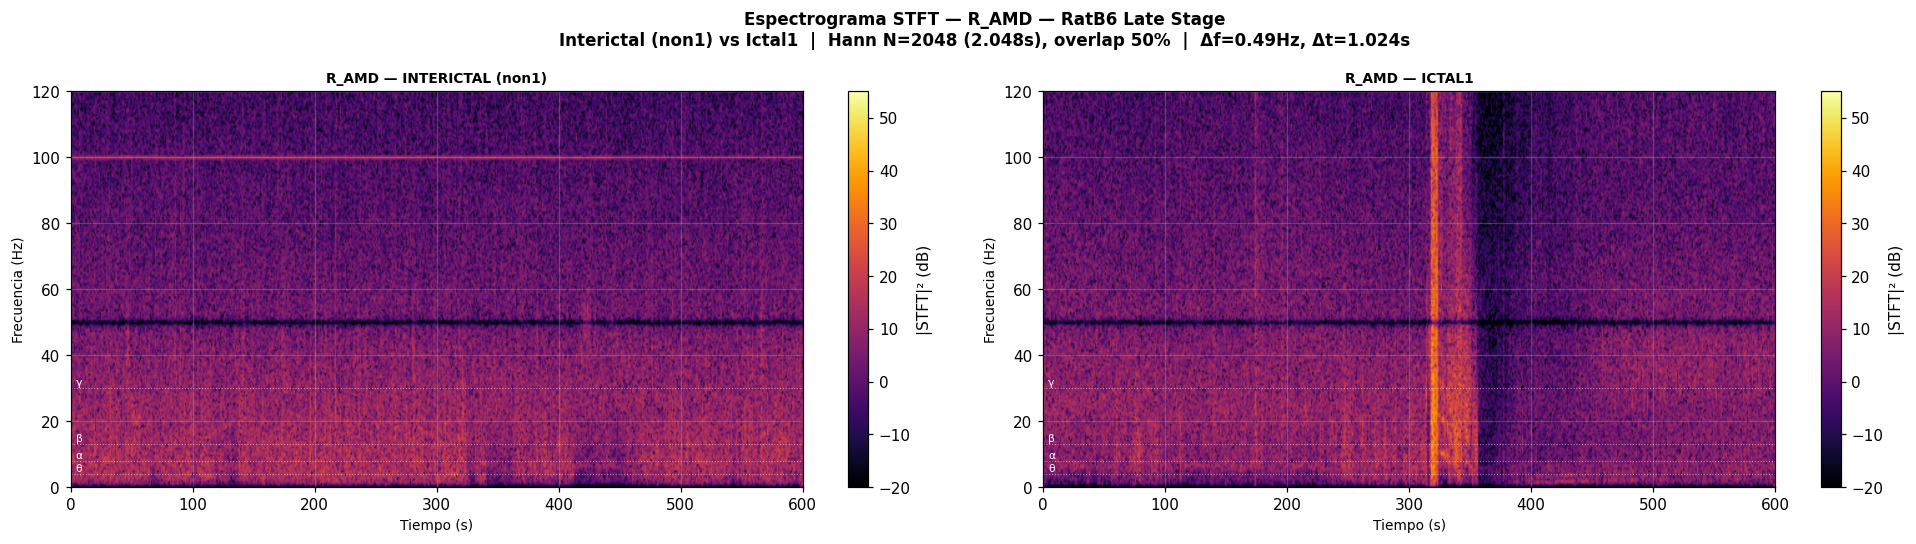

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# ANÁLISIS TIEMPO-FRECUENCIA CON STFT (Espectrograma)
# Comparación interictal (non1) vs ictal1 — un solo canal
# Solo visualización, sin marca de crisis
# ═══════════════════════════════════════════════════════════════════════
from scipy.signal import stft

# ── Parámetros STFT ──────────────────────────────────────────────────
# Trade-off temporal vs frecuencial:
#   Δf = fs / N_perseg = 1000 / 2048 ≈ 0.49 Hz  → separa bandas clínicas
#   Δt = N_perseg / (2 * fs) = 1.024 s           → localiza onset con error <1s
NPERSEG  = 2048          # ventana Hann 2.048s — potencia de 2 (FFT eficiente)
NOVERLAP = NPERSEG // 2  # 50% overlap → paso temporal = 1.024s
FMAX     = 120           # Hz visualizados
CMAP     = 'inferno'
VMIN, VMAX = -20, 55     # rango dinámico común a ambos espectrogramas

CANAL = 'R_AMD'
idx_ch = LABELS.index(CANAL)

sig_non_ch   = datos['non']['filt'][:, idx_ch]
sig_ictal_ch = datos['ictal']['filt'][:, idx_ch]

# Calcular STFT
f_n, t_n, Zxx_n = stft(sig_non_ch,   fs=fs, window='hann',
                        nperseg=NPERSEG, noverlap=NOVERLAP)
f_i, t_i, Zxx_i = stft(sig_ictal_ch, fs=fs, window='hann',
                        nperseg=NPERSEG, noverlap=NOVERLAP)

# |STFT|² en dB
Sxx_n = 20 * np.log10(np.abs(Zxx_n) + 1e-10)
Sxx_i = 20 * np.log10(np.abs(Zxx_i) + 1e-10)
mask_f = f_n <= FMAX

# ── Figura: 1 canal × 2 columnas (non | ictal) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    f'Espectrograma STFT — {CANAL} — RatB6 Late Stage\n'
    f'Interictal (non1) vs Ictal1  |  '
    f'Hann N={NPERSEG} ({NPERSEG/1000:.3f}s), overlap 50%  |  '
    f'Δf={1000/NPERSEG:.2f}Hz, Δt={NPERSEG/2000:.3f}s',
    fontsize=11, fontweight='bold')

# ── Columna izquierda: interictal ────────────────────────────────────
ax = axes[0]
im = ax.pcolormesh(t_n, f_n[mask_f], Sxx_n[mask_f, :],
                   shading='gouraud', cmap=CMAP, vmin=VMIN, vmax=VMAX)
for fb, nm in [(4,'θ'), (8,'α'), (13,'β'), (30,'γ')]:
    ax.axhline(fb, color='white', lw=0.7, ls=':', alpha=0.5)
    ax.text(4, fb + 0.8, nm, color='white', fontsize=7)
ax.set_ylim(0, FMAX)
ax.set_ylabel('Frecuencia (Hz)', fontsize=9)
ax.set_xlabel('Tiempo (s)', fontsize=9)
ax.set_title(f'{CANAL} — INTERICTAL (non1)', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, label='|STFT|² (dB)')

# ── Columna derecha: ictal ───────────────────────────────────────────
ax = axes[1]
im = ax.pcolormesh(t_i, f_i[mask_f], Sxx_i[mask_f, :],
                   shading='gouraud', cmap=CMAP, vmin=VMIN, vmax=VMAX)
for fb, nm in [(4,'θ'), (8,'α'), (13,'β'), (30,'γ')]:
    ax.axhline(fb, color='white', lw=0.7, ls=':', alpha=0.5)
    ax.text(4, fb + 0.8, nm, color='white', fontsize=7)
ax.set_ylim(0, FMAX)
ax.set_ylabel('Frecuencia (Hz)', fontsize=9)
ax.set_xlabel('Tiempo (s)', fontsize=9)
ax.set_title(f'{CANAL} — ICTAL1', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, label='|STFT|² (dB)')

plt.tight_layout()
plt.show()